In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


In [86]:
df = pd.read_excel('J:\\repos\\aiswd-python2\\aiwd\\zaliczenie\\retail.xlsx')

In [87]:
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [88]:
df['CustomerID'] = df['CustomerID'].astype('Int64')
df['InvoiceNo'] = df['InvoiceNo'].astype('str')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  Int64         
 7   Country      541909 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 33.6+ MB


1. Przygotuj dane: 
    * wyklucz faktury zaczynające sie na "A" i te z Quantity > 70 000;
    * wyodrębnij zwroty, zamówienia i straty. 

In [ ]:
cut_off_value = 70000
df_1 = df.query(f"Quantity <= {cut_off_value} or Quantity <= -{cut_off_value}")
print(f'Amount of invoices with quantity over {cut_off_value}:', len(df) - len(df_1))
df_1 = df_1[~df_1['InvoiceNo'].str.startswith('A', na=False)]
print('Amount of invoices with InvoiceNo starting with A:', len(df) - len(df_1))
df_1_orders = df_1[~df_1['InvoiceNo'].str.startswith('C', na=False)]
print('Amount of invoices with InvoiceNo not starting with C (orders):', len(df_1) - len(df_1_orders))
df_1_returns_or_losses = df_1[df_1['InvoiceNo'].str.startswith('C', na=False)]
print('Amount of invoices with InvoiceNo starting with C (returns or losses):', len(df_1) - len(df_1_orders))
df_1_losses = df_1_returns_or_losses[df_1_returns_or_losses['CustomerID'].isna()]
print('Amount of invoices with InvoiceNo starting with C and missing CustomerID (losses):', len(df_1_losses))
df_1_returns = df_1_returns_or_losses[df_1_returns_or_losses['CustomerID'].notna()]
print('Amount of invoices with InvoiceNo starting with C and not missing CustomerID (returns):', len(df_1_returns))
print('=' * 50, 'Orders', '=' * 50)
display(df_1_orders.head())
print('=' * 50, 'Returns', '=' * 50)
display(df_1_returns.head())
print('=' * 50, 'Losses', '=' * 50)
display(df_1_losses.head())
assert len(df_1) == len(df_1_orders) + len(df_1_returns) + len(df_1_losses)

Amount of invoices with quantity over 70000: 2
Amount of invoices with InvoiceNo starting with A: 5
Amount of invoices with InvoiceNo not starting with C (orders): 9288
Amount of invoices with InvoiceNo starting with C (returns or losses): 9288
Amount of invoices with InvoiceNo starting with C and missing CustomerID (losses): 383
Amount of invoices with InvoiceNo starting with C and not missing CustomerID (returns): 8905
================================================== Orders ==================================================


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


================================================== Returns ==================================================


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom


================================================== Losses ==================================================


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
11502,C537251,22429,ENAMEL MEASURING JUG CREAM,-2,2010-12-06 10:45:00,4.25,<NA>,United Kingdom
11503,C537251,22620,4 TRADITIONAL SPINNING TOPS,-8,2010-12-06 10:45:00,1.25,<NA>,United Kingdom
11504,C537251,21890,S/6 WOODEN SKITTLES IN COTTON BAG,-2,2010-12-06 10:45:00,2.95,<NA>,United Kingdom
11505,C537251,22564,ALPHABET STENCIL CRAFT,-5,2010-12-06 10:45:00,1.25,<NA>,United Kingdom
11506,C537251,21891,TRADITIONAL WOODEN SKIPPING ROPE,-3,2010-12-06 10:45:00,1.25,<NA>,United Kingdom


2. Przygotuj zestawienie porównujące produkty zamówione i utracone: 
    * WYNIK - Tabela z kolumnami: 
        - StockCode, 
        - suma quantity dla zamówień
        - średnia (a moze mediana?) z Unit Price dla zamówien 
        - suma quantity dla strat
        - średnia (a moze mediana?) z Unit Price dla strat 
    * PODPOWIEDZ: mozna to zrobić w dwóch krokach: zgrupować i zagregowac dane osobno dla zamówień i strat a następnie połączyc oba zbiory (funkcja merge).

In [ ]:
df_2_orders = df_1_orders.copy()
df_2_losses = df_1_losses.copy()

def aggregate_by_stockcode(df, prefix=''):
    agg_dict = {
        'Quantity': 'sum',
        'UnitPrice': ['mean', 'median']
    }
    
    result = df.groupby('StockCode').agg(agg_dict).reset_index()
    result.columns = ['StockCode', f'{prefix}Quantity_sum', f'{prefix}UnitPrice_avg', f'{prefix}UnitPrice_median']
    
    return result

orders_agg = aggregate_by_stockcode(df_2_orders, prefix='Orders_')
losses_agg = aggregate_by_stockcode(df_2_losses, prefix='Losses_')

comparison_report = orders_agg.merge(losses_agg, on='StockCode', how='outer')

print('Comparison report that calculates Quantity Sum, Median and Avg for both orders and losses:')
display(comparison_report)
print('Comparison report that calculates Quantity Sum, Median and Avg for both orders and losses where given stock code has both values present:')
display(comparison_report.dropna())

Comparison report that calculates Quantity Sum, Median and Avg for both orders and losses:


,StockCode,Orders_Quantity_sum,Orders_UnitPrice_avg,Orders_UnitPrice_median,Losses_Quantity_sum,Losses_UnitPrice_avg,Losses_UnitPrice_median
0,10002,1037,1.056849,0.85,NaN,NaN,NaN
1,10080,495,0.376667,0.39,NaN,NaN,NaN
2,10120,193,0.210000,0.21,NaN,NaN,NaN
3,10125,1296,0.859681,0.85,NaN,NaN,NaN
4,10133,2785,0.646935,0.79,NaN,NaN,NaN
...,...,...,...,...,...,...,...
4052,gift_0001_20,20,15.038000,16.67,NaN,NaN,NaN
4053,gift_0001_30,37,21.941250,25.00,NaN,NaN,NaN
4054,gift_0001_40,3,33.566667,33.33,NaN,NaN,NaN
4055,gift_0001_50,4,41.890000,41.67,NaN,NaN,NaN


Comparison report that calculates Quantity Sum, Median and Avg for both orders and losses where given stock code has both values present:


,StockCode,Orders_Quantity_sum,Orders_UnitPrice_avg,Orders_UnitPrice_median,Losses_Quantity_sum,Losses_UnitPrice_avg,Losses_UnitPrice_median
56,20658,356,1.731560,1.250,-12.0,1.250000,1.25
98,20717,2857,1.672010,1.250,-12.0,1.250000,1.25
99,20718,4776,1.775645,1.250,-11.0,1.250000,1.25
103,20725,19553,2.127373,1.650,-22.0,1.650000,1.65
105,20727,12240,2.098479,1.650,-10.0,1.650000,1.65
...,...,...,...,...,...,...,...
4029,C2,292,49.528169,50.000,-1.0,15.000000,15.00
4046,DOT,1708,290.900945,184.960,-1.0,3.290000,3.29
4047,M,7230,226.624557,1.650,-71.0,501.696667,293.08
4049,POST,6500,30.966575,18.000,-29.0,26.811034,22.56



3. Przygotuj wykres z wielkością strat w poszczególnych miesiacach. Opisz krótko w jaki sposob zdefiniowałaś/eś "wielkość strat" i jak jeszcze inaczej mozna by ją zdefiniować.

C:\Users\s1203137\AppData\Local\temp\ipykernel_1652\2357683535.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(monthly_data['MonthLabel'], rotation=45, ha='right')
C:\Users\s1203137\AppData\Local\temp\ipykernel_1652\2357683535.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(monthly_data['MonthLabel'], rotation=45, ha='right')


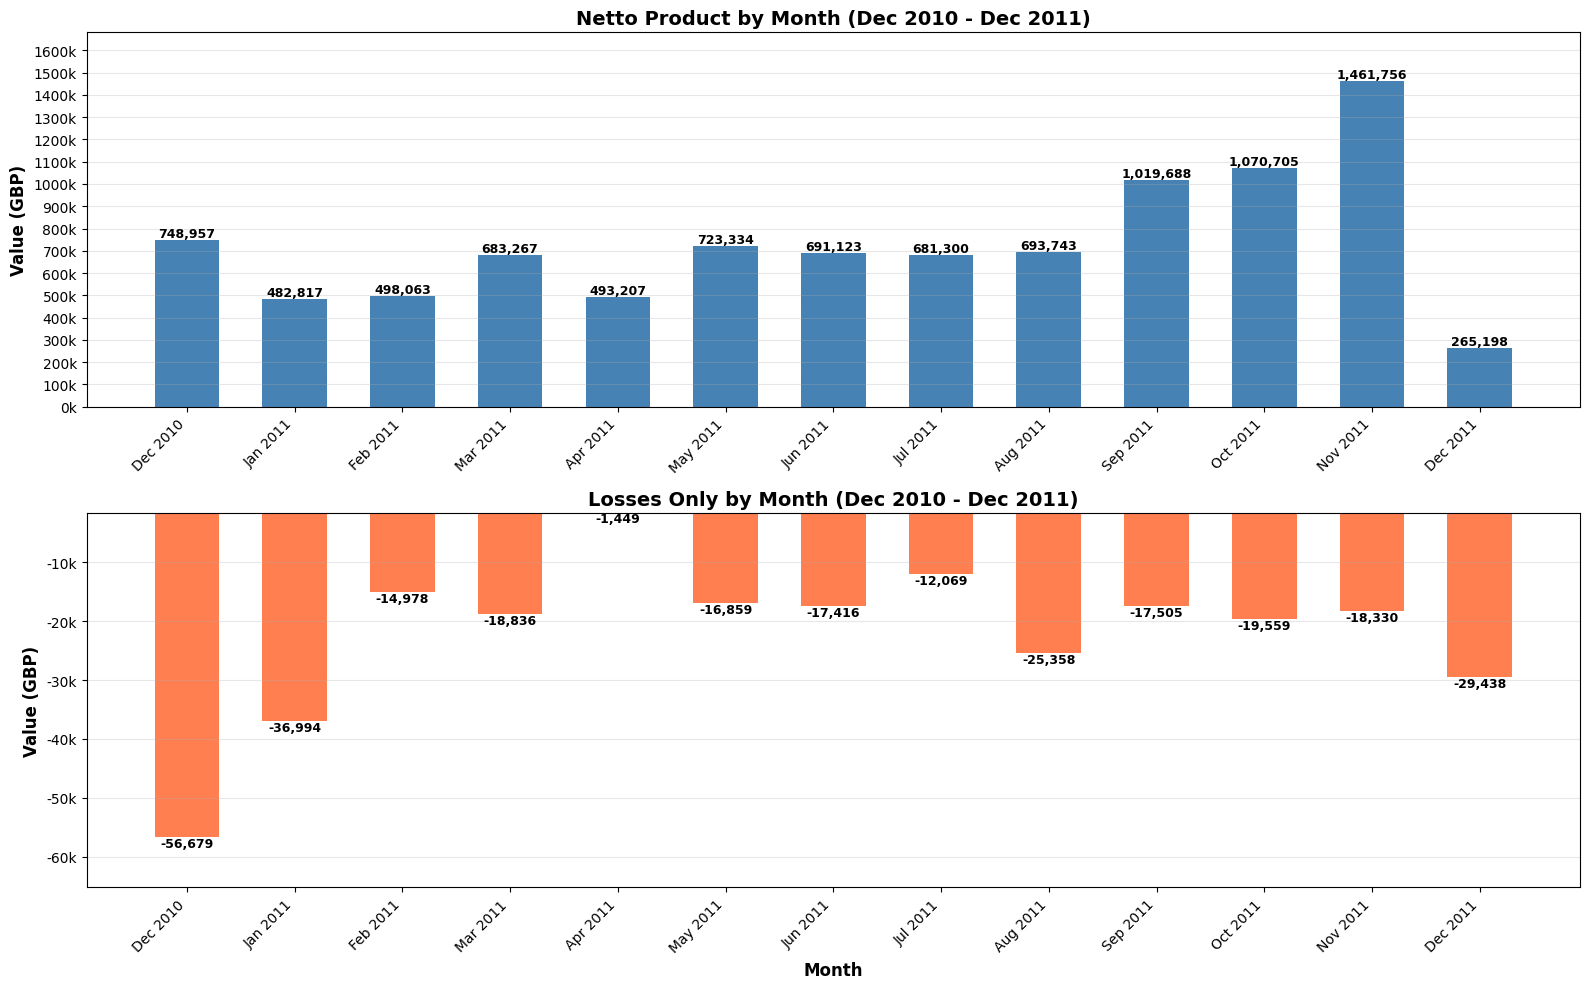

'Monthly netto product and losses by each month from Dec 2010 to Dec 2011:'

'Netto product is presented as combined value of UnitPrice * Quantity for orders, losses and returns, while losses are presented as UnitPrice * Quantity for losses only.'

'However! Losses are also representing operational costs: like amazon fee, bank charges etc. It could be improved by filtering out those values (e.g. how to do it in next cells) and displaying loses only for the products themselves'

'On top of that, returns have sometimes UnitPrice set to 0, therefore it is hard to calculate netto product, without doing magic on resolving original UnitPrice, by manually modifing Invoice Code to get it from original invoice'

**Monthly Summary (Dec 2010 - Dec 2011)**

,MonthLabel,Netto_Product,Losses_Only
0,Dec 2010,748957.020,-56679.25
1,Jan 2011,482816.660,-36993.64
2,Feb 2011,498062.650,-14978.04
3,Mar 2011,683267.080,-18836.13
4,Apr 2011,493207.121,-1448.99
5,May 2011,723333.510,-16859.03
6,Jun 2011,691123.120,-17416.25
7,Jul 2011,681300.111,-12068.55
8,Aug 2011,693742.570,-25357.85
9,Sep 2011,1019687.622,-17504.54


In [ ]:
df_3_orders  = df_1_orders.copy()
df_3_returns = df_1_returns.copy()
df_3_losses  = df_1_losses.copy()

def enrich_with_temporal_and_netto(df):
    """Extract temporal info and calculate netto value (Quantity × UnitPrice)."""
    df['Year'] = df['InvoiceDate'].dt.year
    df['Month'] = df['InvoiceDate'].dt.month
    df['Netto'] = df['Quantity'] * df['UnitPrice']
    return df

def aggregate_monthly_netto(dataframes_dict):
    aggregated = {}
    for name, df in dataframes_dict.items():
        monthly = df.groupby(['Year', 'Month'])['Netto'].sum().reset_index()
        aggregated[name] = monthly.set_index(['Year', 'Month'])['Netto']
    
    result = pd.DataFrame(aggregated).reset_index()
    return result

def add_month_labels(df, month_names=None):
    if month_names is None:
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df['MonthLabel'] = df['Month'].apply(lambda x: month_names[x-1]) + ' ' + df['Year'].astype(str)
    return df

def add_value_labels_to_bars(axes, bars, values, y_offset_fn=lambda v: 'bottom'):
    for bar, value in zip(bars, values):
        height = bar.get_height()
        vertical_align = y_offset_fn(value)
        y_position = height if vertical_align == 'bottom' else height
        axes.text(bar.get_x() + bar.get_width()/2., y_position,
                 f'{value:,.0f}',
                 ha='center', va=vertical_align, fontsize=9, fontweight='bold')

def format_chart_axis(ax, metric_name, is_netto=True):
    ax.set_ylabel('Value (GBP)', fontsize=12, fontweight='bold')
    ax.set_title(f'{metric_name} by Month (Dec 2010 - Dec 2011)', 
                fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    if is_netto:
        ax.yaxis.set_major_locator(plt.MultipleLocator(100000))
    else:
        ax.yaxis.set_major_locator(plt.MultipleLocator(10000))
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

for df in [df_3_orders, df_3_returns, df_3_losses]:
    enrich_with_temporal_and_netto(df)

monthly_data = aggregate_monthly_netto({
    'Orders': df_3_orders,
    'Returns': df_3_returns,
    'Losses': df_3_losses
})

monthly_data['Netto_Product'] = (monthly_data['Orders'] + 
                                 monthly_data['Returns'] + 
                                 monthly_data['Losses'])
monthly_data['Losses_Only'] = monthly_data['Losses']

monthly_data = monthly_data.sort_values(['Year', 'Month']).reset_index(drop=True)
monthly_data = add_month_labels(monthly_data)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
x_pos = np.arange(len(monthly_data))
width = 0.6

bars1 = axes[0].bar(x_pos, monthly_data['Netto_Product'], color='steelblue', width=width)
add_value_labels_to_bars(axes[0], bars1, monthly_data['Netto_Product'])
format_chart_axis(axes[0], 'Netto Product', is_netto=True)
axes[0].set_xticklabels(monthly_data['MonthLabel'], rotation=45, ha='right')
axes[0].set_xticks(x_pos)
axes[0].set_ylim(0, monthly_data['Netto_Product'].max() * 1.15)

bars2 = axes[1].bar(x_pos, monthly_data['Losses_Only'], color='coral', width=width)
add_value_labels_to_bars(axes[1], bars2, monthly_data['Losses_Only'],
                        y_offset_fn=lambda v: 'bottom' if v >= 0 else 'top')
format_chart_axis(axes[1], 'Losses Only', is_netto=False)
axes[1].set_xticklabels(monthly_data['MonthLabel'], rotation=45, ha='right')
axes[1].set_xticks(x_pos)
axes[1].set_xlabel('Month', fontsize=12, fontweight='bold')
min_val, max_val = monthly_data['Losses_Only'].min(), monthly_data['Losses_Only'].max()
axes[1].set_ylim(min_val * 1.15, max_val * 1.15)

plt.tight_layout()
plt.show()

display('Monthly netto product and losses by each month from Dec 2010 to Dec 2011:')
display('Netto product is presented as combined value of UnitPrice * Quantity for orders, losses and returns, while losses are presented as UnitPrice * Quantity for losses only.')
display('However! Losses are also representing operational costs: like amazon fee, bank charges etc. It could be improved by filtering out those values (e.g. how to do it in next cells) and displaying loses only for the products themselves')
display('On top of that, returns have sometimes UnitPrice set to 0, therefore it is hard to calculate netto product, without doing magic on resolving original UnitPrice, by manually modifing Invoice Code to get it from original invoice')
display(Markdown("**Monthly Summary (Dec 2010 - Dec 2011)**"))
display(monthly_data[['MonthLabel', 'Netto_Product', 'Losses_Only']])
plt.show()



1. ze wszystkich dostepnych produktow - jakie produktu sa najczesciej "tracone"? Czy częściej zamawiane produkty sa częściej tracone? 
    - jako wszystkie produkty weź te, które sa dostepne w naszym zbiorze danych i byly zamawiane lub utracone.

In [ ]:

df_4_orders = df_1_orders.copy()
df_4_losses = df_1_losses.copy()

# koszty operacyjne nie sa produktami, wiec nie powinny byc brane pod uwage przy analizie topowych produktow, dlatego je wykluczamy
EXCLUDE_CODES = {'M', 'S', 'AMAZONFEE', 'POST', 'BANK CHARGES', 'DOT', 'C2'}

def get_top_stockcodes(df, metric_type, top_n=10, exclude_codes=None):
    if exclude_codes is None:
        exclude_codes = set()
    
    filtered_df = df[~df['StockCode'].isin(exclude_codes)]
    
    top_products = filtered_df['StockCode'].value_counts().head(top_n).reset_index()
    top_products.columns = ['StockCode', 'Count']
    
    descriptions = filtered_df.drop_duplicates('StockCode')[['StockCode', 'Description']]
    
    top_products = top_products.merge(descriptions, on='StockCode', how='left')
    top_products['Type'] = metric_type
    
    return top_products[['StockCode', 'Description', 'Count', 'Type']]

top_ordered = get_top_stockcodes(df_4_orders, 'Ordered', top_n=20, exclude_codes=EXCLUDE_CODES)
top_lost = get_top_stockcodes(df_4_losses, 'Lost', top_n=20, exclude_codes=EXCLUDE_CODES)

display(Markdown("### Top 20 Most Ordered Products"))
display(top_ordered.reset_index(drop=True))

display(Markdown("### Top 20 Most Lost Products"))
display(top_lost.reset_index(drop=True))

display(Markdown("### Products in Both Top 20 Ordered and Top 20 Lost"))
overlap_codes = set(top_ordered['StockCode']) & set(top_lost['StockCode'])

if overlap_codes:
    overlap_data = []
    for code in overlap_codes:
        desc = top_ordered[top_ordered['StockCode'] == code]['Description'].values[0]
        order_count = top_ordered[top_ordered['StockCode'] == code]['Count'].values[0]
        loss_count = top_lost[top_lost['StockCode'] == code]['Count'].values[0]
        overlap_data.append({
            'StockCode': code,
            'Description': desc,
            'Orders': order_count,
            'Losses': loss_count
        })
    
    overlap_df = pd.DataFrame(overlap_data).sort_values('Orders', ascending=False).reset_index(drop=True)
    display(overlap_df)
else:
    display(Markdown("No products found in both top 20 lists."))


### Top 20 Most Ordered Products

,StockCode,Description,Count,Type
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2271,Ordered
1,85099B,JUMBO BAG RED RETROSPOT,2115,Ordered
2,22423,REGENCY CAKESTAND 3 TIER,2022,Ordered
3,47566,PARTY BUNTING,1707,Ordered
4,20725,LUNCH BAG RED RETROSPOT,1595,Ordered
5,84879,ASSORTED COLOUR BIRD ORNAMENT,1490,Ordered
6,22197,SMALL POPCORN HOLDER,1426,Ordered
7,22720,SET OF 3 CAKE TINS PANTRY DESIGN,1403,Ordered
8,21212,PACK OF 72 RETROSPOT CAKE CASES,1370,Ordered
9,20727,LUNCH BAG BLACK SKULL.,1328,Ordered


### Top 20 Most Lost Products

,StockCode,Description,Count,Type
0,21212,PACK OF 72 RETROSPOT CAKE CASES,3,Lost
1,21888,BINGO SET,2,Lost
2,84929,ASSTD FRUIT+FLOWERS FRIDGE MAGNETS,2,Lost
3,21121,SET/10 RED POLKADOT PARTY CANDLES,2,Lost
4,22398,MAGNETS PACK OF 4 SWALLOWS,2,Lost
5,22945,CHRISTMAS METAL TAGS ASSORTED,2,Lost
6,84879,ASSORTED COLOUR BIRD ORNAMENT,2,Lost
7,22924,FRIDGE MAGNETS LA VIE EN ROSE,2,Lost
8,22567,20 DOLLY PEGS RETROSPOT,2,Lost
9,20725,LUNCH BAG RED RETROSPOT,2,Lost


### Products in Both Top 20 Ordered and Top 20 Lost

,StockCode,Description,Orders,Losses
0,20725,LUNCH BAG RED RETROSPOT,1595,2
1,84879,ASSORTED COLOUR BIRD ORNAMENT,1490,2
2,21212,PACK OF 72 RETROSPOT CAKE CASES,1370,3


2. czy byly stracone jakieś produkty, które nigdy nie byly zamówione?

In [ ]:

df_5_orders = df_1_orders[~df_1_orders['StockCode'].isin(EXCLUDE_CODES)].copy()
df_5_losses = df_1_losses[~df_1_losses['StockCode'].isin(EXCLUDE_CODES)].copy()

ordered_codes = set(df_5_orders['StockCode'].unique())
lost_codes = set(df_5_losses['StockCode'].unique())

lost_only_codes = lost_codes - ordered_codes

if lost_only_codes:
    display(Markdown(f"### Products Lost But Never Ordered (Total: {len(lost_only_codes)})"))
    
    lost_only_data = []
    for code in lost_only_codes:
        desc = df_5_losses[df_5_losses['StockCode'] == code]['Description'].values[0]
        loss_count = len(df_5_losses[df_5_losses['StockCode'] == code])
        lost_only_data.append({
            'StockCode': code,
            'Description': desc,
            'Losses': loss_count
        })
    
    lost_only_df = pd.DataFrame(lost_only_data).sort_values('Losses', ascending=False).reset_index(drop=True)
    display(lost_only_df)
else:
    display(Markdown("No products found that were lost but never ordered."))


No products found that were lost but never ordered.

3. w jakich okresach identyfikowane sa straty? (codziennie czy np. tylko pod koniec tygodnia? czy widać, zeby w jakims okresie było wiecej / mniej strat?)

### Loss Reporting Frequency Analysis


**Basic Statistics:**
- Total loss records: 383
- Unique loss dates: 82
- Total days in period: 365
- Loss reporting rate: 22.47% (losses reported on 82 out of 365 days)
- Average losses per day (with losses): 4.67


### Losses by Day of Week

,DayOfWeek,Count,Percentage
0,Monday,137,35.77
1,Tuesday,114,29.77
2,Wednesday,18,4.70
3,Thursday,33,8.62
4,Friday,78,20.37
5,Saturday,0,0.00
6,Sunday,3,0.78


### Losses by Day of Month (1-31)

...

,Period,Count,Percentage
0,End (21-31),193,50.39
1,Middle (11-20),117,30.55
2,Beginning (1-10),73,19.06


### Losses by Month

,Month,Count,Percentage
0,January,21,5.48
1,February,40,10.44
2,March,54,14.10
3,April,5,1.31
4,May,35,9.14
5,June,60,15.67
6,July,10,2.61
7,August,19,4.96
8,September,13,3.39
9,October,62,16.19


### Time Gaps Between Loss Reports


**Gap Statistics (days between consecutive loss reports):**
- Mean gap: 4.49 days
- Median gap: 3.00 days
- Min gap: 1.0 day(s)
- Max gap: 19.0 days
- Std Dev: 3.85


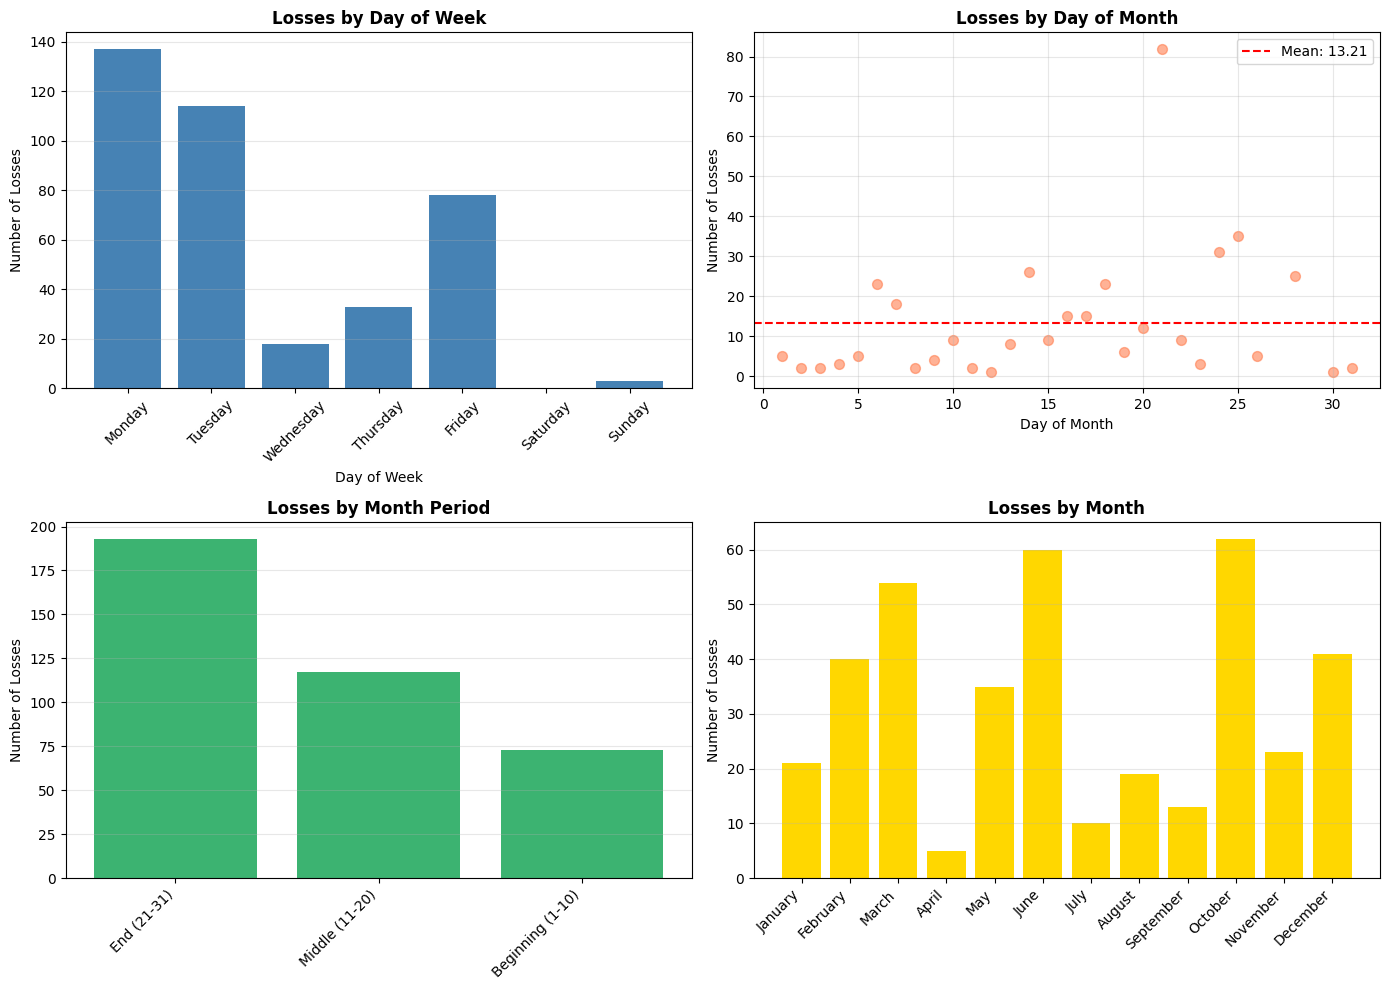

In [ ]:
df_6_losses = df_1_losses.copy()

df_6_losses['Date'] = df_6_losses['InvoiceDate'].dt.date
df_6_losses['DayOfWeek'] = df_6_losses['InvoiceDate'].dt.day_name()
df_6_losses['DayOfMonth'] = df_6_losses['InvoiceDate'].dt.day
df_6_losses['DayOfWeekNum'] = df_6_losses['InvoiceDate'].dt.weekday  # 0=Monday, 6=Sunday
df_6_losses['WeekOfYear'] = df_6_losses['InvoiceDate'].dt.isocalendar().week
df_6_losses['Month'] = df_6_losses['InvoiceDate'].dt.month
df_6_losses['MonthName'] = df_6_losses['InvoiceDate'].dt.month_name()

display(Markdown("### Loss Reporting Frequency Analysis"))

unique_loss_dates = df_6_losses['Date'].nunique()
total_days_in_period = (df_6_losses['InvoiceDate'].max() - df_6_losses['InvoiceDate'].min()).days + 1
loss_reporting_rate = (unique_loss_dates / total_days_in_period) * 100

display(Markdown(f"""
**Basic Statistics:**
- Total loss records: {len(df_6_losses)}
- Unique loss dates: {unique_loss_dates}
- Total days in period: {total_days_in_period}
- Loss reporting rate: {loss_reporting_rate:.2f}% (losses reported on {unique_loss_dates} out of {total_days_in_period} days)
- Average losses per day (with losses): {len(df_6_losses) / unique_loss_dates:.2f}
"""))

display(Markdown("### Losses by Day of Week"))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_analysis = df_6_losses['DayOfWeek'].value_counts().reindex(day_order, fill_value=0)
dow_pct = (dow_analysis / len(df_6_losses) * 100).round(2)

dow_df = pd.DataFrame({
    'DayOfWeek': dow_analysis.index,
    'Count': dow_analysis.values,
    'Percentage': dow_pct.values
}).reset_index(drop=True)

display(dow_df)

display(Markdown("### Losses by Day of Month (1-31)"))

dom_analysis = df_6_losses['DayOfMonth'].value_counts().sort_index()
dom_mean = dom_analysis.mean()
dom_std = dom_analysis.std()
dom_median = dom_analysis.median()

display(Markdown(f"""
**Day of Month Statistics:**
- Mean losses per day: {dom_mean:.2f}
- Median losses per day: {dom_median:.2f}
- Std Dev: {dom_std:.2f}
- Min losses in a day of month: {dom_analysis.min()}
- Max losses in a day of month: {dom_analysis.max()} (Day {dom_analysis.idxmax()})

**Top 5 Days of Month with Most Losses:**
"""))

top_dom = dom_analysis.nlargest(5)
for day, count in top_dom.items():
    display(Markdown(f"- Day {day}: {count} losses ({count/len(df_6_losses)*100:.1f}%)"))

display(Markdown("### Losses by Period of Month"))

df_6_losses['MonthPeriod'] = pd.cut(df_6_losses['DayOfMonth'], 
                                     bins=[0, 10, 20, 31],
                                     labels=['Beginning (1-10)', 'Middle (11-20)', 'End (21-31)'])

period_analysis = df_6_losses['MonthPeriod'].value_counts()
period_pct = (period_analysis / len(df_6_losses) * 100).round(2)

period_df = pd.DataFrame({
    'Period': period_analysis.index,
    'Count': period_analysis.values,
    'Percentage': period_pct.values
}).sort_index()

display(period_df)

display(Markdown("### Losses by Month"))

month_analysis = df_6_losses['MonthName'].value_counts().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
], fill_value=0)
month_pct = (month_analysis / len(df_6_losses) * 100).round(2)

month_df = pd.DataFrame({
    'Month': month_analysis.index,
    'Count': month_analysis.values,
    'Percentage': month_pct.values
}).reset_index(drop=True)

display(month_df[month_df['Count'] > 0])

display(Markdown("### Time Gaps Between Loss Reports"))

sorted_dates = pd.to_datetime(df_6_losses['Date']).sort_values().unique()
time_gaps = pd.Series(sorted_dates).diff().dt.days

display(Markdown(f"""
**Gap Statistics (days between consecutive loss reports):**
- Mean gap: {time_gaps.mean():.2f} days
- Median gap: {time_gaps.median():.2f} days
- Min gap: {time_gaps.min()} day(s)
- Max gap: {time_gaps.max()} days
- Std Dev: {time_gaps.std():.2f}
"""))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(dow_df['DayOfWeek'], dow_df['Count'], color='steelblue')
axes[0, 0].set_title('Losses by Day of Week', fontweight='bold')
axes[0, 0].set_xlabel('Day of Week')
axes[0, 0].set_ylabel('Number of Losses')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].scatter(dom_analysis.index, dom_analysis.values, alpha=0.6, s=50, color='coral')
axes[0, 1].axhline(y=dom_mean, color='red', linestyle='--', label=f'Mean: {dom_mean:.2f}')
axes[0, 1].set_title('Losses by Day of Month', fontweight='bold')
axes[0, 1].set_xlabel('Day of Month')
axes[0, 1].set_ylabel('Number of Losses')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

period_plot_data = period_df[period_df['Count'] > 0].sort_index()
axes[1, 0].bar(range(len(period_plot_data)), period_plot_data['Count'], color='mediumseagreen')
axes[1, 0].set_xticks(range(len(period_plot_data)))
axes[1, 0].set_xticklabels(period_plot_data['Period'], rotation=45, ha='right')
axes[1, 0].set_title('Losses by Month Period', fontweight='bold')
axes[1, 0].set_ylabel('Number of Losses')
axes[1, 0].grid(axis='y', alpha=0.3)

month_plot_data = month_df[month_df['Count'] > 0]
axes[1, 1].bar(range(len(month_plot_data)), month_plot_data['Count'], color='gold')
axes[1, 1].set_xticks(range(len(month_plot_data)))
axes[1, 1].set_xticklabels(month_plot_data['Month'], rotation=45, ha='right')
axes[1, 1].set_title('Losses by Month', fontweight='bold')
axes[1, 1].set_ylabel('Number of Losses')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### WNIOSKI

1. Widac ze wiekszosc start jest raprotowana w poniedzialki i wtorki, czesciowo tez w piatki - bardzo rzadko w niedziele i minimalnie w srody oraz czwartki. 
2. Prawdopodobonie domknieciem okreslu rozliczeniowego jest dzien 21 kazdego miesiaca, poniewaz wtedy jest raportowanych najwiecej strat. 
3. Ogolnie najwiecej start tez jest raportowanych z koncem miesiaca (dni 21-31). 
4. Jesli chodzi o rozklad miesieczny to zauwazalnie mniej strat jest raportowanych w 3 kwartale.

4. czy wartosc (UnitPrice) jest wpisywana przy stratach? zestaw rozkład wartosci UnitPrice dla strat z wartościa wpisywana w zamówieniu - znajdź produkty z najwieksza róznica na wartości średniej i/lub medianie.

In [ ]:
df_7_orders = df_1_orders[~df_1_orders['StockCode'].isin(EXCLUDE_CODES)].copy()
df_7_losses = df_1_losses[~df_1_losses['StockCode'].isin(EXCLUDE_CODES)].copy()

display(Markdown("## Regular products: UnitPrice checks (no charts)"))
display(Markdown(f"- Orders: {len(df_7_orders)}  -  Losses: {len(df_7_losses)}"))

loss_total = df_7_losses.groupby('StockCode').size().rename('Loss_Records')
up_num = pd.to_numeric(df_7_losses['UnitPrice'], errors='coerce').astype('int')
is_zero = df_7_losses[df_7_losses['UnitPrice'] == 0]
loss_missing = (df_7_losses['UnitPrice'].isna() | is_zero['UnitPrice'].notna()).groupby(df_7_losses['StockCode']).sum().rename('Missing_UnitPrice')
loss_missing_df = pd.concat([loss_total, loss_missing], axis=1).fillna(0).reset_index()
loss_missing_df['Missing_Pct'] = (loss_missing_df['Missing_UnitPrice'] / loss_missing_df['Loss_Records'] * 100).round(2)

missing_any_df = loss_missing_df[loss_missing_df['Missing_UnitPrice'] > 0].sort_values('Missing_UnitPrice', ascending=False).reset_index(drop=True)
missing_all_df = loss_missing_df[loss_missing_df['Missing_UnitPrice'] == loss_missing_df['Loss_Records']].reset_index(drop=True)

display(Markdown('### Products with ANY missing UnitPrice in losses'))
display(missing_any_df)

display(Markdown('### Products with ALL loss rows missing UnitPrice'))
display(missing_all_df)

orders_stats = df_7_orders.groupby('StockCode')['UnitPrice'].agg(Orders_Avg='mean', Orders_Median='median').reset_index()
losses_stats = df_7_losses[df_7_losses['UnitPrice'].notna()].groupby('StockCode')['UnitPrice'].agg(Losses_Avg='mean', Losses_Median='median').reset_index()
pc = orders_stats.merge(losses_stats, on='StockCode', how='inner')
pc['Avg_Diff'] = (pc['Losses_Avg'] - pc['Orders_Avg']).abs()
pc['Median_Diff'] = (pc['Losses_Median'] - pc['Orders_Median']).abs()
pc['Avg_Pct'] = np.where(pc['Orders_Avg'] != 0, (pc['Avg_Diff'] / pc['Orders_Avg'] * 100).abs(), np.nan)
pc['Median_Pct'] = np.where(pc['Orders_Median'] != 0, (pc['Median_Diff'] / pc['Orders_Median'] * 100).abs(), np.nan)

# Top 10 tables
top_avg = pc.nlargest(10, 'Avg_Diff')[['StockCode', 'Orders_Avg', 'Losses_Avg', 'Avg_Diff', 'Avg_Pct']].reset_index(drop=True)
top_med = pc.nlargest(10, 'Median_Diff')[['StockCode', 'Orders_Median', 'Losses_Median', 'Median_Diff', 'Median_Pct']].reset_index(drop=True)

display(Markdown('### Top 10 by ABS avg difference'))
display(top_avg.round(2))

display(Markdown('### Top 10 by ABS median difference'))
display(top_med.round(2))

summary_df = pd.DataFrame({
    'Compared_products': [len(pc)],
    'Mean_Abs_Avg_Diff': [pc['Avg_Diff'].mean()],
    'Mean_Abs_Median_Diff': [pc['Median_Diff'].mean()]
}).round(2)

display(Markdown('### Summary'))
display(summary_df)


## Regular products: UnitPrice checks (no charts)

- Orders: 530292  -  Losses: 165

### Products with ANY missing UnitPrice in losses

,StockCode,Loss_Records,Missing_UnitPrice,Missing_Pct


### Products with ALL loss rows missing UnitPrice

...

,StockCode,Orders_Avg,Losses_Avg,Avg_Diff,Avg_Pct
0,22947,13.02,33.17,20.15,154.81
1,22178,1.64,14.75,13.11,797.69
2,84945,0.95,10.76,9.81,1030.58
3,23056,6.05,1.00,5.05,83.47
4,23055,5.50,1.00,4.50,81.83
5,23057,4.69,1.00,3.69,78.70
6,22960,5.07,8.29,3.22,63.59
7,37500,7.21,9.95,2.74,37.98
8,21658,5.55,8.29,2.74,49.28
9,22461,10.20,12.75,2.55,25.03


### Top 10 by ABS median difference

,StockCode,Orders_Median,Losses_Median,Median_Diff,Median_Pct
0,22947,7.95,33.17,25.22,317.23
1,22178,1.25,14.75,13.50,1080.00
2,84945,0.85,10.76,9.91,1165.88
3,23055,6.25,1.00,5.25,84.00
4,23056,6.25,1.00,5.25,84.00
5,21658,3.95,8.29,4.34,109.87
6,22503,20.79,24.95,4.16,20.01
7,22960,4.25,8.29,4.04,95.06
8,23057,4.95,1.00,3.95,79.80
9,21792,3.95,6.75,2.80,70.89


### Summary

,Compared_products,Mean_Abs_Avg_Diff,Mean_Abs_Median_Diff
0,154,0.95,0.62


5. jaki jest rozklad strat w poszczególnych miesiacach / tygodniach? - czy lepszą miarą bedzie liczba (Quantity) czy wartość? 

In [ ]:
import calendar

df_weekly = df_6_losses.copy()
df_weekly['AbsQuantity'] = df_weekly['Quantity'].abs()
df_weekly['AbsValue'] = (pd.to_numeric(df_weekly['UnitPrice'], errors='coerce') * df_weekly['Quantity']).abs()

weekly_qty = df_weekly.groupby('WeekOfYear')['AbsQuantity'].sum().rename('Quantity_Sum').reset_index()
weekly_value = df_weekly.groupby('WeekOfYear')['AbsValue'].sum().rename('Value_Sum').reset_index()
weekly_summary = weekly_qty.merge(weekly_value, on='WeekOfYear').sort_values('WeekOfYear').reset_index(drop=True)

monthly_qty = df_weekly.groupby('Month')['AbsQuantity'].sum().rename('Quantity_Sum').reset_index()
monthly_value = df_weekly.groupby('Month')['AbsValue'].sum().rename('Value_Sum').reset_index()
monthly_summary = monthly_qty.merge(monthly_value, on='Month')
monthly_summary['MonthName'] = monthly_summary['Month'].apply(lambda m: calendar.month_name[m])
monthly_summary = monthly_summary.sort_values('Month').reset_index(drop=True)

display(Markdown('### Weekly loss distribution (absolute quantity and absolute value)'))
display(weekly_summary)

display(Markdown('### Monthly loss distribution (absolute quantity and absolute value)'))
display(monthly_summary[['Month','MonthName','Quantity_Sum','Value_Sum']])

### Weekly loss distribution (absolute quantity and absolute value)

,WeekOfYear,Quantity_Sum,Value_Sum
0,1,58,34040.85
1,2,5,27.75
2,3,11,2909.05
3,4,3,15.99
4,5,29,52.15
5,6,1,7.95
6,7,3,2871.71
7,8,33,12046.23
8,9,12,10.20
9,10,3,1087.10


### Monthly loss distribution (absolute quantity and absolute value)

,Month,MonthName,Quantity_Sum,Value_Sum
0,1,January,77,36993.64
1,2,February,66,14978.04
2,3,March,863,18836.13
3,4,April,5,1448.99
4,5,May,35,16859.03
5,6,June,585,17416.25
6,7,July,14,12068.55
7,8,August,20,25357.85
8,9,September,26,17504.54
9,10,October,299,19559.43


Z danych wynika ze lepiej uzyc Quantity * UnitPrice do prezentacji strat, zamiast samego quantity, poniewaz proporcje miedzy tymi danymi nie sa wymierne (np. tydzien 40 - 26 strat, na wartosc 30.9, z kolei w tygodniu 38 - 8 strat na wartosc 2607.48)

6. Na jakie kraje zapisywane są straty?

In [97]:
countries = sorted(df_1_losses['Country'].dropna().unique())
display(Markdown('### Unique countries in losses'))
display(pd.DataFrame({'Country': countries, 'Count': [ (df_1_losses['Country']==c).sum() for c in countries]}))

### Unique countries in losses

,Country,Count
0,Bahrain,1
1,EIRE,55
2,Hong Kong,4
3,United Kingdom,323


7. Czy jakies rekordy (produkty, wartosci) wydaja sie dziwne w tym zestawieniu?

In [98]:
df = df.copy()
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce').astype('int')

df_1_orders = df_1_orders.copy()
df_1_losses = df_1_losses.copy()
df_1_returns = df_1_returns.copy()

neg_orders = df_1_orders[df_1_orders['Quantity'] < 0]
pos_losses = df_1_losses[df_1_losses['Quantity'] > 0]
pos_returns = df_1_returns[df_1_returns['Quantity'] > 0]
zero_price_all = df[df['UnitPrice'] == 0]

display(Markdown('### Checks: Quantity / Price Issues'))

display(pd.DataFrame({
    'Check': ['Negative Quantity in Orders', 'Positive Quantity in Losses', 'Positive Quantity in Returns', 'Zero UnitPrice (all)'],
    'Count': [len(neg_orders), len(pos_losses), len(pos_returns), len(zero_price_all)]
}))

if len(neg_orders):
    display(Markdown('#### Sample negative quantities in orders'))
    display(neg_orders[['InvoiceNo','StockCode','Description','Quantity','UnitPrice']].head(10))

if len(pos_losses):
    display(Markdown('#### Sample positive quantities in losses'))
    display(pos_losses[['InvoiceNo','StockCode','Description','Quantity','UnitPrice']].head(10))

if len(pos_returns):
    display(Markdown('#### Sample positive quantities in returns'))
    display(pos_returns[['InvoiceNo','StockCode','Description','Quantity','UnitPrice']].head(10))

if len(zero_price_all):
    display(Markdown('#### Sample rows with UnitPrice == 0'))
    display(zero_price_all[['InvoiceNo','StockCode','Description','Quantity','UnitPrice']].head(10))


### Checks: Quantity / Price Issues

,Check,Count
0,Negative Quantity in Orders,1336
1,Positive Quantity in Losses,0
2,Positive Quantity in Returns,0
3,Zero UnitPrice (all),36


#### Sample negative quantities in orders

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
2406,536589,21777,NaN,-10,0.0
4347,536764,84952C,NaN,-38,0.0
7188,536996,22712,NaN,-20,0.0
7189,536997,22028,NaN,-20,0.0
7190,536998,85067,NaN,-6,0.0
7192,537000,21414,NaN,-22,0.0
7193,537001,21653,NaN,-6,0.0
7195,537003,85126,NaN,-2,0.0
7196,537004,21814,NaN,-30,0.0
7197,537005,21692,NaN,-70,0.0


#### Sample rows with UnitPrice == 0

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
11514,C537251,22418,10 COLOUR SPACEBOY PEN,-7,0
11519,C537251,22536,MAGIC DRAWING SLATE PURDEY,-11,0
108126,C545506,22907,PACK OF 20 NAPKINS PANTRY DESIGN,-12,0
133108,C547725,22924,FRIDGE MAGNETS LA VIE EN ROSE,-72,0
133109,C547725,84929,ASSTD FRUIT+FLOWERS FRIDGE MAGNETS,-144,0
133110,C547725,84929,ASSTD FRUIT+FLOWERS FRIDGE MAGNETS,-144,0
133112,C547725,23230,WRAP ALPHABET DESIGN,-25,0
133115,C547725,22948,METAL DECORATION NAUGHTY CHILDREN,-6,0
133116,C547725,22945,CHRISTMAS METAL TAGS ASSORTED,-6,0
133117,C547725,22945,CHRISTMAS METAL TAGS ASSORTED,-72,0


Dziwne jest to, ze koszty operacyjne (EXCLUDED_CODES) zostaly uwzglednione jako produkty w tym rozliczeniu, powinny to byc osobne dane
Dodatkowo sa zwroty, ktore maja podany UnitPrice 0, gdzie nie wiadomo czy chodzi o ta sama cene co z faktury wyjsciowej? Zaburza to liczenie produktu netto
Oprocz tego w zamowieniach sa ujemne wartosci i cena produktu podana jako zero. Byc moze gdyby format danych byl opisany na wejsciu, dlaczego podjete sa takie decyzje to byloby prosciej. Niestety przy braku takich informacji na starcie, metoda inzynierii wstecznej w celu dowiedzenia sie tych rzeczy utrudnia zadanie.